Regarding extraction of data for analysis of website users, the following SQL query was used, to extract information from posthog's system. 

PostHog's in built AI editor helped correct mistakes in the SQL query before running. 

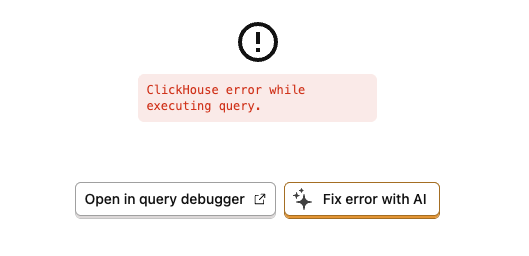

In [1]:
from IPython import display
display.Image("Screenshot 2026-05-13 at 13.51.36.png")

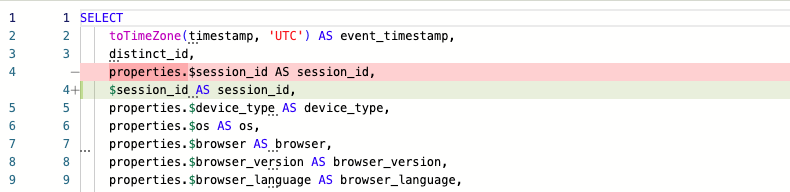

In [3]:
from IPython import display
display.Image("Screenshot 2026-05-13 at 13.55.01.png")

In [4]:
SELECT
    s.session_id,
    s.distinct_id,
    s.$start_timestamp AS session_start,
    s.$end_timestamp AS session_end,
    s.$session_duration AS duration_seconds,
    round(s.$session_duration / 60.0, 1) AS duration_minutes,
    s.$is_bounce AS is_bounce,
    s.$channel_type AS channel_type,
    s.$entry_referring_domain AS referring_domain,
    s.$entry_utm_source AS utm_source,
    s.$entry_utm_campaign AS utm_campaign,
    s.$entry_utm_medium AS utm_medium,
    s.$num_uniq_urls AS unique_urls_visited,
    s.$vitals_lcp AS lcp_ms,
    any(e.properties.$geoip_country_name) AS country,
    any(e.properties.$geoip_country_code) AS country_code,
    any(e.properties.$geoip_region_name) AS region,
    any(e.properties.$geoip_city_name) AS city,
    any(e.properties.$device_type) AS device_type,
    any(e.properties.$os) AS operating_system,
    any(e.properties.$browser) AS browser,
    any(e.properties.$browser_version) AS browser_version,
    s.$autocapture_count AS click_count,
    s.$pageview_count AS pageview_count,
    s.$screen_count AS screen_count,
    s.$entry_current_url AS landing_page,
    s.$entry_pathname AS landing_pathname,
    s.$entry_hostname AS landing_hostname,
    s.$end_current_url AS exit_page,
    s.$end_pathname AS exit_pathname,
    count(DISTINCT e.properties.$current_url) AS unique_pages_visited
FROM sessions s
INNER JOIN events e ON e.$session_id = s.session_id
GROUP BY
    s.session_id,
    s.distinct_id,
    s.$start_timestamp,
    s.$end_timestamp,
    s.$session_duration,
    s.$is_bounce,
    s.$channel_type,
    s.$entry_referring_domain,
    s.$entry_utm_source,
    s.$entry_utm_campaign,
    s.$entry_utm_medium,
    s.$num_uniq_urls,
    s.$vitals_lcp,
    s.$autocapture_count,
    s.$pageview_count,
    s.$screen_count,
    s.$entry_current_url,
    s.$entry_pathname,
    s.$entry_hostname,
    s.$end_current_url,
    s.$end_pathname
ORDER BY session_start DESC

IndentationError: unexpected indent (3307796391.py, line 2)

the following sql queries were written to extract data from the parsewise demo project. 

1. core event data
2. autocapture element details
3. device, browser, geography
4. sessions
5. persons

In [ ]:
-- 1. Detailed event-level data for sessions starting from March 4, 2026, excluding events from parsewise.ai email addresses

SELECT
    event,
    toTimeZone(timestamp, 'UTC') AS event_timestamp,
    distinct_id,
    $session_id AS session_id,
    toString(person_id) AS person_id,
    person.properties.email AS person_email,
    if(notEmpty(person.properties.email), true, false) AS is_identified,
    $group_0 AS organization_key,
    properties.$current_url AS current_url,
    properties.$pathname AS pathname,
    properties.$host AS host,
    properties.$referrer AS referrer,
    properties.$referring_domain AS referring_domain
FROM events
WHERE timestamp >= '2026-03-04T00:00:00'
  AND timestamp <= '2026-05-13T23:59:59'
  AND NOT ilike(coalesce(toString(person.properties.email), ''), '%@parsewise.ai%')
LIMIT 100000

In [ ]:
-- 2. Detailed event-level data for autocapture events starting from March 4, 2026, excluding events from parsewise.ai email addresses

SELECT
    toTimeZone(timestamp, 'UTC') AS event_timestamp,
    distinct_id,
    $session_id AS session_id,
    properties.$event_type AS event_type,
    properties.$el_text AS element_text,
    properties.$href AS element_href,
    properties.$elements_chain AS elements_chain,
    properties.$current_url AS current_url,
    properties.$pathname AS pathname
FROM events
WHERE event = '$autocapture'
  AND timestamp >= '2026-03-04T00:00:00'
  AND timestamp <= '2026-05-13T23:59:59'
  AND NOT ilike(coalesce(toString(person.properties.email), ''), '%@parsewise.ai%')
LIMIT 100000

In [ ]:
-- 3. device, browswer, and geolocation details for events starting from March 4, 2026, excluding events from parsewise.ai email addresses

SELECT
    toTimeZone(timestamp, 'UTC') AS event_timestamp,
    distinct_id,
    $session_id AS session_id,
    properties.$device_type AS device_type,
    properties.$os AS os,
    properties.$browser AS browser,
    properties.$browser_version AS browser_version,
    properties.$browser_language AS browser_language,
    properties.$viewport_width AS viewport_width,
    properties.$viewport_height AS viewport_height,
    properties.$screen_width AS screen_width,
    properties.$screen_height AS screen_height,
    properties.$geoip_country_name AS country,
    properties.$geoip_subdivision_1_name AS region,
    properties.$geoip_city_name AS city,
    properties.$geoip_time_zone AS timezone,
    properties.$lib AS sdk_library,
    properties.$lib_version AS sdk_version
FROM events
WHERE NOT ilike(properties.email, '%@parsewise.ai')
  AND timestamp >= '2026-03-04T00:00:00'
ORDER BY distinct_id, event_timestamp

In [ ]:
-- 4. sessions starting from March 4, 2026, excluding sessions from parsewise.ai email addresses

SELECT
    session_id,
    $start_timestamp AS start_timestamp,
    $end_timestamp AS end_timestamp,
    $session_duration AS session_duration_seconds,
    $pageview_count AS pageview_count,
    $autocapture_count AS autocapture_count,
    $entry_current_url AS entry_url,
    $entry_pathname AS entry_pathname,
    $entry_referring_domain AS entry_referring_domain,
    $exit_current_url AS exit_url,
    $exit_pathname AS exit_pathname,
    $end_pathname AS end_pathname,
    distinct_id,
    $is_bounce AS is_bounce,
    $channel_type AS channel_type
FROM sessions
WHERE $start_timestamp >= toDateTime('2026-03-04 00:00:00')
ORDER BY $start_timestamp ASC

In [ ]:
-- 5. persons 

SELECT
    toString(id) AS person_id,
    toTimeZone(created_at, 'UTC') AS created_at,
    properties.email AS email,
    JSONExtractString(properties, 'auth0_org_id') AS auth0_org_id,
    JSONExtractString(properties, '$initial_referrer') AS initial_referrer,
    JSONExtractString(properties, '$initial_referring_domain') AS initial_referring_domain,
    JSONExtractString(properties, '$initial_geoip_country_name') AS initial_country,
    JSONExtractString(properties, '$initial_device_type') AS initial_device_type,
    JSONExtractString(properties, '$initial_os') AS initial_os,
    JSONExtractString(properties, '$initial_browser') AS initial_browser,
    JSONExtractString(properties, '$initial_channel_type') AS initial_channel_type,
    JSONExtractString(properties, 'utm_source') AS utm_source,
    JSONExtractString(properties, 'utm_medium') AS utm_medium,
    JSONExtractString(properties, 'utm_campaign') AS utm_campaign,
    JSONExtractString(properties, 'gclid') AS gclid,
    JSONExtractString(properties, 'fbclid') AS fbclid,
    JSONExtractString(properties, 'li_fat_id') AS li_fat_id
FROM persons
WHERE properties.email NOT ILIKE '%@parsewise.ai%'
ORDER BY created_at ASC

IndentationError: unexpected indent (911536592.py, line 2)

I then decided to streamline later data extractions, to reduce the amount of individual sheets

1. Events Master
This is the main raw table. It includes all event types, autocapture detail, URL context, device/browser/geo fields, and person identifiers.

In [ ]:
SELECT
    event,
    timestamp AS event_timestamp,
    distinct_id,

    person.id AS person_id,
    person.properties.email AS person_email,
    if(person.id IS NULL, 0, 1) AS is_identified,

    properties.$session_id AS session_id,
    properties.$current_url AS current_url,
    properties.$pathname AS pathname,
    properties.$host AS host,
    properties.$referrer AS referrer,
    properties.$referring_domain AS referring_domain,

    properties.$event_type AS event_type,
    properties.$el_text AS element_text,
    properties.$el_href AS element_href,
    properties.$elements_chain AS elements_chain,

    properties.$browser AS browser,
    properties.$browser_version AS browser_version,
    properties.$browser_language AS browser_language,
    properties.$os AS os,
    properties.$device_type AS device_type,
    properties.$screen_width AS screen_width,
    properties.$screen_height AS screen_height,
    properties.$viewport_width AS viewport_width,
    properties.$viewport_height AS viewport_height,
    properties.$geoip_country_name AS country,
    properties.$geoip_subdivision_1_name AS region,
    properties.$geoip_city_name AS city,
    properties.$geoip_time_zone AS timezone,

    properties.$lib AS sdk_library,
    properties.$lib_version AS sdk_version,

    properties
FROM events
WHERE properties.$host = 'demo.parsewise.ai'
ORDER BY timestamp ASC

2. Sessions Summary
One row per session.

In [ ]:
SELECT
    properties.$session_id AS session_id,
    min(timestamp) AS start_timestamp,
    max(timestamp) AS end_timestamp,
    dateDiff('second', min(timestamp), max(timestamp)) AS session_duration_seconds,

    countIf(event = '$pageview') AS pageview_count,
    countIf(event = '$autocapture') AS autocapture_count,

    argMin(properties.$current_url, timestamp) AS entry_url,
    argMin(properties.$pathname, timestamp) AS entry_pathname,
    argMin(properties.$referring_domain, timestamp) AS entry_referring_domain,

    argMax(properties.$current_url, timestamp) AS exit_url,
    argMax(properties.$pathname, timestamp) AS exit_pathname,
    argMax(properties.$pathname, timestamp) AS end_pathname,

    any(distinct_id) AS distinct_id,

    if(countIf(event != '$pageview') = 0 AND countIf(event = '$pageview') <= 1, 1, 0) AS is_bounce
FROM events
WHERE properties.$host = 'demo.parsewise.ai'
  AND properties.$session_id IS NOT NULL
GROUP BY properties.$session_id
ORDER BY start_timestamp ASC

3. Persons
One row per person.

In [ ]:
SELECT
    id AS person_id,
    created_at,
    properties.email AS email,
    properties.auth0_org_id AS auth0_org_id,
    properties.initial_referrer AS initial_referrer,
    properties.initial_referring_domain AS initial_referring_domain,
    properties.initial_country AS initial_country,
    properties.initial_device_type AS initial_device_type,
    properties.initial_os AS initial_os,
    properties.initial_browser AS initial_browser,
    properties.initial_channel_type AS initial_channel_type,
    properties.utm_source AS utm_source,
    properties.utm_medium AS utm_medium,
    properties.utm_campaign AS utm_campaign,
    properties.gclid AS gclid,
    properties.fbclid AS fbclid,
    properties.li_fat_id AS li_fat_id
FROM persons
ORDER BY created_at ASC